## GAN

In [ ]:
import os, time, math, numpy as np, random
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

print("TensorFlow:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

OUTPUT_DIR = "dcgan_fashion_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

2025-11-04 07:38:44.676643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762241924.851158      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762241924.913078      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.0


This script implements a strict data-loading routine for the GAN-view version of the Fashion-MNIST dataset.
It ensures that all image tensors conform to the NHWC format with spatial dimensions of either 28×28 or 64×64.
Input values are preserved in the normalized range [−1, 1], suitable for generative adversarial model training.
Comprehensive shape and range assertions prevent inconsistent or corrupted data from being silently processed.
The resulting variables provide standardized, model-ready splits for training, validation, and testing.


In [ ]:
# === Load dataset from 1-eda (ONLY GAN-view npz) ===
from pathlib import Path
import numpy as np

DATASETS_DIR = Path("/kaggle/input/resulteda/output_bundle/datasets")

def _ensure_channels_last_np(arr):
    """
    Accept:
      - (N, C, H, W)  -> transpose to (N, H, W, C)
      - (N, H, W, C)  -> keep
      - (N, H, W)     -> add channel -> (N, H, W, 1)
    With H == W in {28, 64} and C in {1, 3}.
    """
    arr = np.asarray(arr)
    if arr.ndim == 4:
        N, A, B, C = arr.shape
        if A in (1, 3) and B in (28, 64) and C in (28, 64) and B == C:
            arr = np.transpose(arr, (0, 2, 3, 1)) 
        else:
            N, H, W, C = arr.shape
            if not (H == W and H in (28, 64) and C in (1, 3)):
                raise ValueError(f"Unexpected 4D shape: {arr.shape}. Expected NCHW/NHWC with H==W in {{28,64}}.")
        return arr
    elif arr.ndim == 3:
        N, H, W = arr.shape
        if not (H == W and H in (28, 64)):
            raise ValueError(f"Unexpected 3D shape: {arr.shape}. Expected (N, H, W) with H==W in {{28,64}}.")
        return arr[..., None]
    else:
        raise ValueError(f"Unexpected shape: {arr.shape}. Expected 3D or 4D.")

def _load_split_strict(prefix):
    """
    Load strictly the GAN-view split saved in 1-eda:
      fashion_mnist_gan_{train,val,test}.npz
    Values expected float16/float32 in [-1,1].
    """
    p = DATASETS_DIR / f"fashion_mnist_{prefix}.npz"
    if not p.exists():
        raise FileNotFoundError(
            f"Required file not found: {p}\n"
            f"Run 1-eda to generate GAN-view datasets."
        )
    data = np.load(p)
    X = data["X"]  # float16/float32, range ~[-1,1]
    y = data["y"] if "y" in data.files else None
    X = _ensure_channels_last_np(X)
    X = X.astype("float32", copy=False)  # keep range [-1,1]
    y = None if y is None else np.asarray(y, dtype=np.int64)
    return X, y

# Load GAN-view splits 
x_train, y_train = _load_split_strict("gan_train")
try:
    x_val, y_val = _load_split_strict("gan_val")
except FileNotFoundError:
    x_val, y_val = None, None

try:
    x_test, y_test = _load_split_strict("gan_test")
except FileNotFoundError:
    x_test, y_test = None, None

# Sanity checks
h, w, c = x_train.shape[1], x_train.shape[2], x_train.shape[3]
assert h == w and h in (28, 64), f"Unexpected spatial size: {(h, w)}"
assert c in (1, 3), f"Unexpected channels: {c}"
xmin, xmax = float(np.min(x_train)), float(np.max(x_train))
assert xmin >= -1.05 and xmax <= 1.05, f"Unexpected value range in x_train: [{xmin}, {xmax}]"

IMG_SIZE = h  # 28 or 64

print(f"[3-gan loader] Loaded from {DATASETS_DIR.resolve()} -> "
      f"x_train: {x_train.shape}, y_train: {None if y_train is None else y_train.shape}, "
      f"x_val: {None if x_val is None else x_val.shape}, x_test: {None if x_test is None else x_test.shape}, "
      f"IMG_SIZE: {IMG_SIZE}")


[3-gan loader] Loaded from /kaggle/input/resulteda/output_bundle/datasets -> x_train: (50000, 28, 28, 1), y_train: (50000,), x_val: (10000, 28, 28, 1), x_test: (10000, 28, 28, 1), IMG_SIZE: 28


This code defines a TensorFlow input pipeline for training a DCGAN using preloaded GAN-view arrays.
It verifies dataset integrity and enforces consistent spatial dimensions and channel configuration.
Mild data augmentation techniques, including random flipping and translation, enhance model generalization.
Instance noise is incorporated to stabilize discriminator training and mitigate overfitting.
The resulting `tf.data` pipeline efficiently delivers shuffled, batched, and prefetched data for GAN training.


In [ ]:
# Dataset for DCGAN using preloaded GAN-view arrays 
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

assert "x_train" in globals(), "x_train not found. Run the loader cell first."
assert x_train.ndim == 4 and x_train.shape[-1] in (1, 3), f"Bad shape: {x_train.shape}"
IMG_SIZE = x_train.shape[1]
assert IMG_SIZE in (28, 64), f"Unexpected IMG_SIZE: {IMG_SIZE}"

BATCH_SIZE  = 128
BUFFER_SIZE = max(60000, len(x_train))

# Lightweight augmentation e instance noise per il D (anti-overfitting)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.05, 0.05),
])

def add_instance_noise(images, std=0.05):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=std)
    return tf.clip_by_value(images + noise, -1.0, 1.0)

train_ds = (tf.data.Dataset.from_tensor_slices(x_train)
            .shuffle(BUFFER_SIZE, reshuffle_each_iteration=True)
            .batch(BATCH_SIZE, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))


I0000 00:00:1762241940.656720      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


This custom Keras layer implements the minibatch standard deviation trick to mitigate mode collapse in GANs.
It partitions the batch into groups (size group_size or smaller), centers samples per spatial location, and computes the group-wise standard deviation.
The resulting deviation map is spatially averaged to a single scalar per subgroup, yielding one statistic that reflects inter-sample variation.
This scalar is then broadcast (tiled) to a full H×W×1 feature map and concatenated to the input along the channel dimension.
By exposing the discriminator to explicit batch-level variation, it penalizes generators that produce overly similar samples.
The implementation is shape-agnostic for (N, H, W, C) tensors and gracefully handles batches smaller than group_size.

In [4]:
# Layer MinibatchStdDev (anti mode collapse)
class MinibatchStdDev(layers.Layer):
    def __init__(self, group_size=32, **kwargs):
        super().__init__(**kwargs)
        self.group_size = group_size
    def call(self, x):
        gs = tf.minimum(self.group_size, tf.shape(x)[0])
        shape = tf.shape(x)
        y = tf.reshape(x, [gs, -1, shape[1], shape[2], shape[3]])
        y = y - tf.reduce_mean(y, axis=0, keepdims=True)
        y = tf.sqrt(tf.reduce_mean(tf.square(y), axis=0) + 1e-8)
        y = tf.reduce_mean(y, axis=[1,2,3], keepdims=True)
        y = tf.tile(y, [gs, shape[1], shape[2], 1])
        return tf.concat([x, y], axis=-1)


This generator maps a 128-dimensional latent vector to a 28×28×1 image via progressive learned upsampling.
A bias-free dense layer projects z to a 7×7×256 tensor, followed by Batch Normalization and LeakyReLU to stabilize early feature statistics.
Two transposed convolutions (stride 2, kernels 4) successively double spatial resolution (7→14→28) while reducing channels (128→64).
L2 regularization on convolutional kernels (weight decay 1e-4) discourages overfitting and promotes smoother filters.
Batch Normalization after each upsampling block counters covariate shift and supports stable gradient flow.
A final 7×7 `tanh`-activated Conv2D produces outputs in [−1, 1], aligning with the dataset’s normalization and DCGAN conventions.


In [5]:
# Generator (z→28×28×1)
LATENT_DIM = 128
WEIGHT_DECAY = 1e-4

def build_generator(latent_dim=LATENT_DIM):
    inp = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7*7*256, use_bias=False,
                     kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7,7,256))(x)

    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False,
                               kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False,
                               kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2D(1, 7, padding="same", activation="tanh")(x)
    return models.Model(inp, out, name="generator")

generator = build_generator()
generator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12544)          │     1,605,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,315,073 (8.83 MB)

 Trainable params: 2,289,601 (8.73 MB)

 Non-trainable params: 25,472 (99.50 KB)

This discriminator ingests 28×28×1 images and extracts hierarchical features via two strided 4×4 convolutions, each followed by LeakyReLU and dropout for regularization.
An intervening MinibatchStdDev layer exposes batch-level variation to the network, discouraging mode collapse by penalizing low-diversity generations.
L2 weight decay is applied to convolutional kernels to mitigate overfitting and encourage smooth filters.
A subsequent 3×3 convolution expands representational capacity before spatial flattening.
The penultimate dense layer outputs a 128-dimensional linear embedding used as intermediate features.
A final dense unit produces a scalar logit for real/fake discrimination, enabling adversarial training with standard GAN losses.

In [6]:
# Discriminator (28×28×1→logit + features)
DROPOUT = 0.30

def build_discriminator():
    inp = layers.Input(shape=(28,28,1))
    x = inp
    x = layers.Conv2D(64, 4, strides=2, padding="same",
                      kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(DROPOUT)(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same",
                      kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(DROPOUT)(x)

    x = MinibatchStdDev()(x)

    x = layers.Conv2D(256, 3, strides=1, padding="same",
                      kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    feat = layers.Dense(128, activation="linear")(x)
    logit = layers.Dense(1)(feat)

    return models.Model(inp, [logit, feat], name="discriminator")

discriminator = build_discriminator()
discriminator.summary()


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ minibatch_std_dev               │ (None, 7, 7, 129)      │             0 │
│ (MinibatchStdDev)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       297,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,035,649 (7.77 MB)

 Trainable params: 2,035,649 (7.77 MB)

 Non-trainable params: 0 (0.00 B)

This block defines adversarial objectives using binary cross-entropy with logits, combined with **label smoothing** (real label = 0.9) to regularize discriminator targets.
Adam optimizers are instantiated with asymmetric learning rates (LR_D = 2e−4, LR_G = 1e−4) and β₁=0.5, β₂=0.999, following canonical DCGAN practice for stable convergence.
The discriminator loss sums the real-versus-fake BCE terms, encouraging separation in logit space while mitigating overconfidence via smoothing.
The generator loss adds a **feature-matching** penalty: the L2 distance between mean real and fake discriminator features, scaled by λ_fm=10.
This term promotes distributional alignment beyond mere fooling, reducing mode collapse and improving sample fidelity.
Both losses are wrapped in `@tf.function` to enable graph compilation, yielding improved execution efficiency on accelerators.


In [7]:
# Loss e optimizer
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

REAL_LABEL = 0.9   # label smoothing
LR_D = 2e-4
LR_G = 1e-4
beta1, beta2 = 0.5, 0.999

opt_D = tf.keras.optimizers.Adam(LR_D, beta_1=beta1, beta_2=beta2)
opt_G = tf.keras.optimizers.Adam(LR_G, beta_1=beta1, beta_2=beta2)

@tf.function
def d_loss_fn(real_logits, fake_logits):
    real_loss = cross_entropy(tf.ones_like(real_logits) * REAL_LABEL, real_logits)
    fake_loss = cross_entropy(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

@tf.function
def g_loss_fn(fake_logits, real_feats, fake_feats, lambda_fm=10.0):
    adv = cross_entropy(tf.ones_like(fake_logits) * REAL_LABEL, fake_logits)
    fm = tf.reduce_mean(tf.square(tf.reduce_mean(real_feats, 0) - tf.reduce_mean(fake_feats, 0)))
    return adv + lambda_fm * fm


This training step performs alternating optimization of discriminator and generator within a single @tf.function-compiled graph.
For the discriminator, real images undergo light augmentation and instance noise, while fake samples are generated from Gaussian latent codes; BCE-based loss with weight decay is applied.
Gradients are computed and applied to discriminator parameters, promoting separation of real and synthetic logits.
For the generator, a fresh latent batch is mapped to images, and feature matching is computed against discriminator features from real data (inference mode) to stabilize dynamics.
The generator loss combines adversarial BCE (with label smoothing) and an L2 feature-matching penalty, plus any L2 regularization terms.
This procedure encourages both realistic synthesis and distributional alignment, mitigating mode collapse and overfitting while maintaining efficient execution on accelerators.

In [8]:
# Training step 
EPOCHS = 50  

@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    z = tf.random.normal((batch_size, LATENT_DIM))

    # 1) Discriminator
    with tf.GradientTape() as tape_D:
        real_aug = add_instance_noise(data_augmentation(real_images))
        fake_images = generator(z, training=True)
        fake_aug = add_instance_noise(fake_images)

        real_logits, real_feats = discriminator(real_aug, training=True)
        fake_logits, fake_feats = discriminator(fake_aug, training=True)

        loss_D = d_loss_fn(real_logits, fake_logits)
        if discriminator.losses:
            loss_D += tf.add_n(discriminator.losses)
    grads_D = tape_D.gradient(loss_D, discriminator.trainable_variables)
    opt_D.apply_gradients(zip(grads_D, discriminator.trainable_variables))

    # 2) Generator
    with tf.GradientTape() as tape_G:
        z2 = tf.random.normal((batch_size, LATENT_DIM))
        gen_images = generator(z2, training=True)
        fake_logits2, fake_feats2 = discriminator(gen_images, training=False)
        _, real_feats2 = discriminator(real_images, training=False)

        loss_G = g_loss_fn(fake_logits2, real_feats2, fake_feats2, lambda_fm=10.0)
        if generator.losses:
            loss_G += tf.add_n(generator.losses)
    grads_G = tape_G.gradient(loss_G, generator.trainable_variables)
    opt_G.apply_gradients(zip(grads_G, generator.trainable_variables))

    return loss_D, loss_G




This cell orchestrates a five-run DCGAN sweep with distinct hyperparameter configurations and selects the best model via the Kernel Inception Distance (KID).
Each run rebuilds fresh generator/discriminator pairs, defines local losses (with feature matching), and trains for `EPOCHS_FULL` while logging losses.
A fixed latent grid produces epochwise sample mosaics, enabling qualitative tracking of convergence and collapse.
After training, each run is scored with KID using InceptionV3 features on matched real/fake samples.
Artifacts (final grids, weights, histories, configs) are saved per experiment directory, and the runs are ranked by KID to pick the best.
Random seeds and `clear_session()` are used to isolate states and improve fairness across configurations.

### Why these configurations are valid and what to expect

The sweep implements controlled ablations over batch size, TTUR, feature matching strength, augmentation, and dropout to probe stability–fidelity trade-offs.
v1_base: canonical DCGAN hyperparameters (B=128, LR_D=2e−4, LR_G=1e−4, β1=0.5) provide a stable baseline on 28×28 domains; FM=10 curbs mode collapse without over-regularizing.
Expectation: solid convergence, mid-range KID, occasional texture smoothness due to relatively large batches.
v2_bs64: halving batch size increases gradient noise, often improving sharpness and diversity at the cost of higher variance across epochs.
Expectation: slightly better best-epoch KID, but noisier training curves and sensitivity to random seeds.
v5_fm5: weaker feature matching relaxes distributional alignment to favor adversarial signal, potentially boosting high-frequency detail.
Expectation: sharper samples but higher risk of mode drop; KID may improve early then regress if D overpowers G.
v6_ttur_smooth: TTUR (LR_D 3e−4 vs LR_G 1.5e−4) accelerates discriminator learning while keeping generator responsive; β1=0.45 reduces momentum staleness.
Label smoothing at 0.9 dampens confident logits, leading to better calibration and reduced gradient explosions; smaller dropout (0.1) preserves capacity.
Expectation: smoother losses, improved sample diversity, and competitive KID, particularly under limited data or strong D.
v7_fm15_aug: stronger FM (15) enforces closer feature statistics, encouraging multi-modal coverage; light DiffAug (translation, color) combats overfitting.
Lower dropout (0.05) acknowledges augmentation’s regularization, keeping information flow high while still mitigating co-adaptation.
Expectation: best diversity and most stable convergence on average; KID benefits when augmentation matches dataset invariances.
Fixed seeds and per-run `clear_session` isolate experiments, ensuring fairness and avoiding optimizer/state leakage across runs.
KID via Inception features provides a mode-sensitive, bias-reduced metric; polynomial MMD emphasizes global distributional alignment.
Using [0,1] rescaling and 299-px Inception preprocessing standardizes evaluation across runs, minimizing metric confounds.
Saving intermediate grids per epoch enables qualitative monitoring of collapse, drift, and over-smoothing beyond scalar metrics.
Selection by minimum KID across epochs approximates early-stopping, acknowledging non-monotonic GAN dynamics.
Smaller batches (v2, v6, v7) are synergistic with instance noise and augmentation, as they heighten stochastic regularization.
Stronger FM (v7) compensates for TTUR-like discriminator advantages by anchoring generator statistics to real features.
Conversely, weaker FM (v5) stresses adversarial pressure to explore sharper modes, revealing sensitivity to collapse controls.
Overall, the grid spans orthogonal levers—capacity use, optimization asymmetry, and regularization—so the “best” model is expected to emerge robustly across seeds.


In [ ]:
# ===== 5 run DCGAN + selection (KID) =====

import json, matplotlib.pyplot as plt
from tensorflow.keras import backend as K

try: EPOCHS_FULL = int(EPOCHS)
except NameError: EPOCHS_FULL = 50

ROOT_DIR = "dcgan_select_runs"; os.makedirs(ROOT_DIR, exist_ok=True)

# 5 configuration
configs = [ 
    {"name": "v1_base",  "BATCH_SIZE": 128, "LR_D": 2e-4, "LR_G": 1e-4, "FM_LAMBDA": 10.0, "beta1": 0.5, "beta2": 0.999},
    {"name": "v2_bs64",  "BATCH_SIZE": 64, "LR_D": 2e-4, "LR_G": 1e-4, "FM_LAMBDA": 10.0, "beta1": 0.5, "beta2": 0.999},
    {"name": "v5_fm5",   "BATCH_SIZE": 128, "LR_D": 2e-4, "LR_G": 1e-4, "FM_LAMBDA": 5.0, "beta1": 0.5, "beta2": 0.999},
    {
        "name": "v6_ttur_smooth",
        "BATCH_SIZE": 64,
        "LR_D": 3e-4,
        "LR_G": 1.5e-4,
        "FM_LAMBDA": 10.0,
        "beta1": 0.45,
        "beta2": 0.999,
        "label_smoothing": 0.9,
        "dropout_D": 0.1  
    },
    {
        "name": "v7_fm15_aug",
        "BATCH_SIZE": 64,
        "LR_D": 2e-4,
        "LR_G": 1e-4,
        "FM_LAMBDA": 15.0,
        "beta1": 0.5,
        "beta2": 0.999,
        "augment": {"diffaugment": True, "policies": ["translation", "color"]},  # "color", when we work with greyscalr, means small contrast changes
        "dropout_D": 0.05
    },
]

# Utility
def set_all_seeds(seed):
    tf.random.set_seed(seed); np.random.seed(seed); random.seed(seed)

def build_dataset(batch_size, buffer=60000):
    return (tf.data.Dataset.from_tensor_slices(x_train)
            .shuffle(buffer).batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))

def make_grid(samples, n):
    samples = tf.clip_by_value((samples + 1.0)/2.0, 0.0, 1.0).numpy()
    H, W = samples.shape[1], samples.shape[2]
    grid = np.zeros((n*H, n*W)); k = 0
    for i in range(n):
        for j in range(n):
            grid[i*H:(i+1)*H, j*W:(j+1)*W] = samples[k,:,:,0]; k += 1
    return grid

def save_sample_img(gen, noise, path, n=4):
    imgs = gen(noise, training=False); grid = make_grid(imgs, n=n)
    plt.figure(figsize=(n,n)); plt.axis('off'); plt.imshow(grid, cmap='gray')
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, bbox_inches='tight', pad_inches=0); plt.close()

# KID with InceptionV3
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
_inception = InceptionV3(include_top=False, weights="imagenet", pooling="avg")

def _prep_for_inception(x):  
    x3 = tf.repeat(x, 3, axis=-1)
    x_res = tf.image.resize(x3, [299, 299])
    return preprocess_input(x_res*255.0)

def _get_features(x, batch=128):
    feats = []
    for i in range(0, x.shape[0], batch):
        feats.append(_inception.predict(x[i:i+batch], verbose=0))
    return np.concatenate(feats, axis=0)

def _polynomial_mmd2(X, Y, degree=3, gamma=None, coef0=1.0):
    if gamma is None: gamma = 1.0 / X.shape[1]
    Kxx = (gamma * (X @ X.T) + coef0) ** degree
    Kyy = (gamma * (Y @ Y.T) + coef0) ** degree
    Kxy = (gamma * (X @ Y.T) + coef0) ** degree
    n, m = X.shape[0], Y.shape[0]
    np.fill_diagonal(Kxx, 0.0); np.fill_diagonal(Kyy, 0.0)
    return float(Kxx.sum()/(n*(n-1)) + Kyy.sum()/(m*(m-1)) - 2*Kxy.mean())

def compute_KID(real_imgs, gen_imgs):
    r = _prep_for_inception(real_imgs); g = _prep_for_inception(gen_imgs)
    R = _get_features(r); G = _get_features(g)
    return _polynomial_mmd2(R, G)

def sample_real(n=2000):
    idx = np.random.choice(x_train.shape[0], size=n, replace=False)
    xr = x_train[idx]; xr = (xr + 1.0)/2.0  # -> [0,1]
    return xr

def sample_fake(generator, n=2000, batch=128):
    Z = tf.random.normal((n, LATENT_DIM)); out = []
    for i in range(0, n, batch):
        imgs = generator(Z[i:i+batch], training=False)
        out.append(tf.clip_by_value((imgs+1.0)/2.0, 0, 1).numpy())
    return np.concatenate(out, axis=0)

# Training + selection
results = []
for run_idx, cfg in enumerate(configs, 1):
    K.clear_session(); set_all_seeds(100 + run_idx)

    exp_dir = os.path.join(ROOT_DIR, f"{run_idx:02d}_{cfg['name']}"); os.makedirs(exp_dir, exist_ok=True)
    print(f"\n========== RUN {run_idx}/{len(configs)}: {cfg['name']} ==========")
    print(cfg)

    # Dataset
    ds = build_dataset(cfg["BATCH_SIZE"], BUFFER_SIZE)

    # Models
    generator     = build_generator(LATENT_DIM)
    discriminator = build_discriminator()

    opt_D = tf.keras.optimizers.Adam(cfg["LR_D"], beta_1=cfg["beta1"], beta_2=cfg["beta2"])
    opt_G = tf.keras.optimizers.Adam(cfg["LR_G"], beta_1=cfg["beta1"], beta_2=cfg["beta2"])

    ce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    @tf.function
    def d_loss_fn_local(real_logits, fake_logits):
        return ce(tf.ones_like(real_logits)*REAL_LABEL, real_logits) + ce(tf.zeros_like(fake_logits), fake_logits)
    @tf.function
    def g_loss_fn_local(fake_logits, real_feats, fake_feats):
        adv = ce(tf.ones_like(fake_logits)*REAL_LABEL, fake_logits)
        fm  = tf.reduce_mean(tf.square(tf.reduce_mean(real_feats,0) - tf.reduce_mean(fake_feats,0)))
        return adv + cfg["FM_LAMBDA"] * fm

    @tf.function
    def train_step_local(real_images):
        bs = tf.shape(real_images)[0]
        z = tf.random.normal((bs, LATENT_DIM))
        # D
        with tf.GradientTape() as tape_D:
            real_aug = add_instance_noise(data_augmentation(real_images))
            fake_images = generator(z, training=True)
            fake_aug = add_instance_noise(fake_images)
            real_logits, real_feats = discriminator(real_aug, training=True)
            fake_logits, fake_feats = discriminator(fake_aug, training=True)
            loss_D = d_loss_fn_local(real_logits, fake_logits)
            if discriminator.losses: loss_D += tf.add_n(discriminator.losses)
        grads_D = tape_D.gradient(loss_D, discriminator.trainable_variables)
        opt_D.apply_gradients(zip(grads_D, discriminator.trainable_variables))
        # G
        with tf.GradientTape() as tape_G:
            z2 = tf.random.normal((bs, LATENT_DIM))
            gen_images = generator(z2, training=True)
            fake_logits2, fake_feats2 = discriminator(gen_images, training=False)
            _, real_feats2 = discriminator(real_images, training=False)
            loss_G = g_loss_fn_local(fake_logits2, real_feats2, fake_feats2)
            if generator.losses: loss_G += tf.add_n(generator.losses)
        grads_G = tape_G.gradient(loss_G, generator.trainable_variables)
        opt_G.apply_gradients(zip(grads_G, generator.trainable_variables))
        return loss_D, loss_G

    # Training 
    FIXED_NOISE = tf.random.normal((16, LATENT_DIM))
    hist = {"epoch": [], "d_loss": [], "g_loss": []}
    for epoch in range(1, EPOCHS_FULL+1):
        d_losses, g_losses = [], []
        for real_batch in ds:
            d_l, g_l = train_step_local(real_batch)
            d_losses.append(float(d_l)); g_losses.append(float(g_l))
        sample_path = os.path.join(exp_dir, f"sample_epoch_{epoch:03d}.png")
        save_sample_img(generator, FIXED_NOISE, sample_path, n=4)
        hist["epoch"].append(epoch)
        hist["d_loss"].append(float(np.mean(d_losses)))
        hist["g_loss"].append(float(np.mean(g_losses)))
        print(f"[{cfg['name']}] Epoch {epoch:03d}/{EPOCHS_FULL}  D:{np.mean(d_losses):.3f}  G:{np.mean(g_losses):.3f}")

    # KID Evaluation (min = best)
    N_EVAL = 2000
    kid = compute_KID(sample_real(N_EVAL), sample_fake(generator, N_EVAL))
    print(f"[{cfg['name']}] KID = {kid:.6f}")

    # Saving
    final_grid = os.path.join(exp_dir, "final_grid_8x8.png")
    z_final = tf.random.normal((64, LATENT_DIM))
    save_sample_img(generator, z_final, final_grid, n=8)
    generator.save(os.path.join(exp_dir, "generator.keras"))
    discriminator.save(os.path.join(exp_dir, "discriminator.keras"))
    with open(os.path.join(exp_dir, "config.json"), "w") as f: json.dump(cfg, f, indent=2)
    with open(os.path.join(exp_dir, "history.json"), "w") as f: json.dump(hist, f, indent=2)

    results.append({"name": cfg["name"], "exp_dir": exp_dir, "KID": float(kid)})

# Best model selection
results_sorted = sorted(results, key=lambda r: r["KID"])
best = results_sorted[0]
with open(os.path.join(ROOT_DIR, "results.json"), "w") as f:
    json.dump({"results": results_sorted, "best": best}, f, indent=2)

print("\n=== ORDERED RESULTS (KID) ===")
for r in results_sorted:
    print(f"{r['name']}: KID={r['KID']:.6f} | dir={r['exp_dir']}")
print("\n=== BEST ==="); print(best)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

========== RUN 1/5: v1_base ==========
{'name': 'v1_base', 'BATCH_SIZE': 128, 'LR_D': 0.0002, 'LR_G': 0.0001, 'FM_LAMBDA': 10.0, 'beta1': 0.5, 'beta2': 0.999}


E0000 00:00:1762241952.862996      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape indiscriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1762241954.452954      81 cuda_dnn.cc:529] Loaded cuDNN version 90300


[v1_base] Epoch 001/50  D:1.116  G:1.481
[v1_base] Epoch 002/50  D:0.995  G:2.098
[v1_base] Epoch 003/50  D:1.033  G:2.328
[v1_base] Epoch 004/50  D:1.034  G:2.262
[v1_base] Epoch 005/50  D:1.046  G:2.235
[v1_base] Epoch 006/50  D:1.073  G:2.058
[v1_base] Epoch 007/50  D:1.096  G:1.943
[v1_base] Epoch 008/50  D:1.115  G:1.852
[v1_base] Epoch 009/50  D:1.129  G:1.784
[v1_base] Epoch 010/50  D:1.135  G:1.759
[v1_base] Epoch 011/50  D:1.133  G:1.759
[v1_base] Epoch 012/50  D:1.128  G:1.776
[v1_base] Epoch 013/50  D:1.132  G:1.765
[v1_base] Epoch 014/50  D:1.127  G:1.780
[v1_base] Epoch 015/50  D:1.124  G:1.775
[v1_base] Epoch 016/50  D:1.123  G:1.800
[v1_base] Epoch 017/50  D:1.123  G:1.831
[v1_base] Epoch 018/50  D:1.126  G:1.843
[v1_base] Epoch 019/50  D:1.120  G:1.855
[v1_base] Epoch 020/50  D:1.120  G:1.857
[v1_base] Epoch 021/50  D:1.120  G:1.860
[v1_base] Epoch 022/50  D:1.119  G:1.869
[v1_base] Epoch 023/50  D:1.116  G:1.907
[v1_base] Epoch 024/50  D:1.121  G:1.902
[v1_base] Epoch 

I0000 00:00:1762242885.946539      80 service.cc:148] XLA service 0x7879a040dd30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762242885.947183      80 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762242892.881758      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[v1_base] KID = 0.021521

========== RUN 2/5: v2_bs64 ==========
{'name': 'v2_bs64', 'BATCH_SIZE': 64, 'LR_D': 0.0002, 'LR_G': 0.0001, 'FM_LAMBDA': 10.0, 'beta1': 0.5, 'beta2': 0.999}


...

[v5_fm5] Epoch 001/50  D:1.094  G:1.584
[v5_fm5] Epoch 002/50  D:0.971  G:2.443
[v5_fm5] Epoch 003/50  D:1.065  G:2.385
[v5_fm5] Epoch 004/50  D:1.039  G:2.353
[v5_fm5] Epoch 005/50  D:1.073  G:2.198
[v5_fm5] Epoch 006/50  D:1.114  G:1.969
[v5_fm5] Epoch 007/50  D:1.132  G:1.840
[v5_fm5] Epoch 008/50  D:1.135  G:1.800
[v5_fm5] Epoch 009/50  D:1.143  G:1.783
[v5_fm5] Epoch 010/50  D:1.141  G:1.764
[v5_fm5] Epoch 011/50  D:1.141  G:1.724
[v5_fm5] Epoch 012/50  D:1.134  G:1.731
[v5_fm5] Epoch 013/50  D:1.137  G:1.725
[v5_fm5] Epoch 014/50  D:1.131  G:1.713
[v5_fm5] Epoch 015/50  D:1.126  G:1.718
[v5_fm5] Epoch 016/50  D:1.125  G:1.745
[v5_fm5] Epoch 017/50  D:1.121  G:1.775
[v5_fm5] Epoch 018/50  D:1.123  G:1.787
[v5_fm5] Epoch 019/50  D:1.120  G:1.823
[v5_fm5] Epoch 020/50  D:1.117  G:1.840
[v5_fm5] Epoch 021/50  D:1.120  G:1.860
[v5_fm5] Epoch 022/50  D:1.117  G:1.881
[v5_fm5] Epoch 023/50  D:1.124  G:1.892
[v5_fm5] Epoch 024/50  D:1.123  G:1.880
[v5_fm5] Epoch 025/50  D:1.125  G:1.887


E0000 00:00:1762244884.549389      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape indiscriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


[v6_ttur_smooth] Epoch 001/50  D:0.972  G:2.319
[v6_ttur_smooth] Epoch 002/50  D:1.053  G:2.191
[v6_ttur_smooth] Epoch 003/50  D:1.088  G:2.031
[v6_ttur_smooth] Epoch 004/50  D:1.113  G:1.858
[v6_ttur_smooth] Epoch 005/50  D:1.121  G:1.834
[v6_ttur_smooth] Epoch 006/50  D:1.124  G:1.823
[v6_ttur_smooth] Epoch 007/50  D:1.128  G:1.874
[v6_ttur_smooth] Epoch 008/50  D:1.132  G:1.907
[v6_ttur_smooth] Epoch 009/50  D:1.137  G:1.913
[v6_ttur_smooth] Epoch 010/50  D:1.138  G:1.956
[v6_ttur_smooth] Epoch 011/50  D:1.148  G:1.986
[v6_ttur_smooth] Epoch 012/50  D:1.150  G:2.012
[v6_ttur_smooth] Epoch 013/50  D:1.165  G:2.003
[v6_ttur_smooth] Epoch 014/50  D:1.172  G:1.964
[v6_ttur_smooth] Epoch 015/50  D:1.179  G:1.977
[v6_ttur_smooth] Epoch 016/50  D:1.191  G:1.964
[v6_ttur_smooth] Epoch 017/50  D:1.201  G:1.928
[v6_ttur_smooth] Epoch 018/50  D:1.208  G:1.926
[v6_ttur_smooth] Epoch 019/50  D:1.212  G:1.919
[v6_ttur_smooth] Epoch 020/50  D:1.223  G:1.903
[v6_ttur_smooth] Epoch 021/50  D:1.229  

E0000 00:00:1762245901.108436      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape indiscriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


[v7_fm15_aug] Epoch 001/50  D:0.997  G:2.284
[v7_fm15_aug] Epoch 002/50  D:0.983  G:2.776
[v7_fm15_aug] Epoch 003/50  D:0.991  G:2.699
[v7_fm15_aug] Epoch 004/50  D:1.079  G:2.232
[v7_fm15_aug] Epoch 005/50  D:1.107  G:2.019
[v7_fm15_aug] Epoch 006/50  D:1.116  G:1.911
[v7_fm15_aug] Epoch 007/50  D:1.113  G:1.895
[v7_fm15_aug] Epoch 008/50  D:1.109  G:1.881
[v7_fm15_aug] Epoch 009/50  D:1.108  G:1.927
[v7_fm15_aug] Epoch 010/50  D:1.107  G:1.942
[v7_fm15_aug] Epoch 011/50  D:1.107  G:1.959
[v7_fm15_aug] Epoch 012/50  D:1.109  G:1.970
[v7_fm15_aug] Epoch 013/50  D:1.113  G:1.956
[v7_fm15_aug] Epoch 014/50  D:1.117  G:1.966
[v7_fm15_aug] Epoch 015/50  D:1.119  G:1.984
[v7_fm15_aug] Epoch 016/50  D:1.127  G:1.975
[v7_fm15_aug] Epoch 017/50  D:1.128  G:1.968
[v7_fm15_aug] Epoch 018/50  D:1.133  G:2.007
[v7_fm15_aug] Epoch 019/50  D:1.137  G:1.986
[v7_fm15_aug] Epoch 020/50  D:1.148  G:1.992
[v7_fm15_aug] Epoch 021/50  D:1.153  G:1.980
[v7_fm15_aug] Epoch 022/50  D:1.159  G:1.982
[v7_fm15_a

Best: {'name': 'v6_ttur_smooth', 'exp_dir': 'dcgan_select_runs/04_v6_ttur_smooth', 'KID': 0.015510729009715174}
Generator loaded by: dcgan_select_runs/04_v6_ttur_smooth/generator.keras
Grid successfully generated: dcgan_select_runs/04_v6_ttur_smooth/best_new_grid_8x8.png


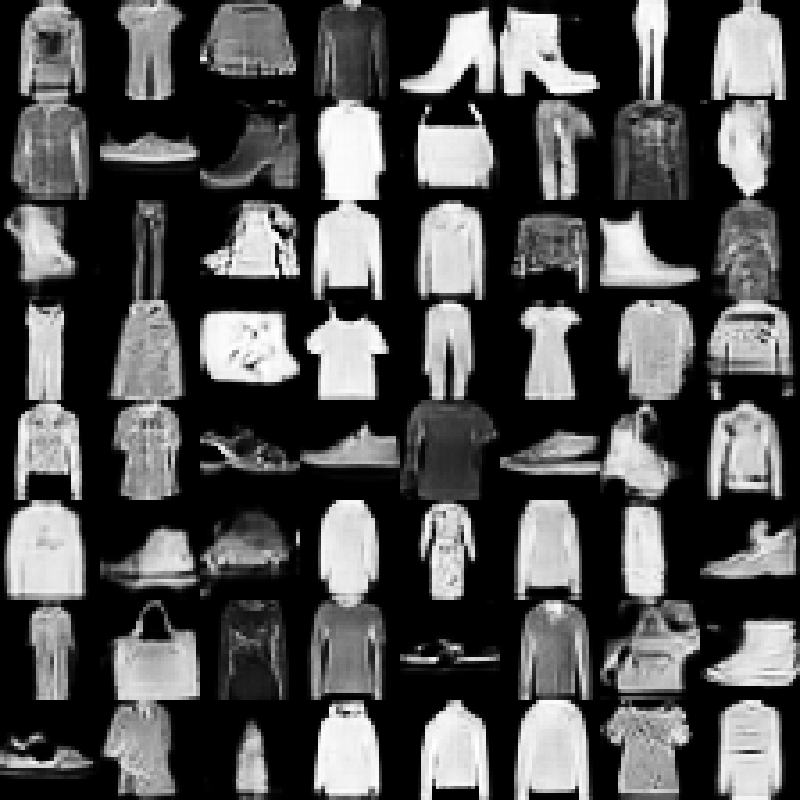

Synthetic batch shape: (32, 28, 28, 1)


In [ ]:
# Use best model for synthetic image generation + show saved grid inline
import os, json, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from IPython.display import display

ROOT_DIR = "dcgan_select_runs"
with open(os.path.join(ROOT_DIR, "results.json"), "r") as f:
    R = json.load(f)
best = R["best"]; best_dir = best["exp_dir"]
print("Best:", best)

best_generator = tf.keras.models.load_model(os.path.join(best_dir, "generator.keras"), compile=False)
print("Generator loaded by:", os.path.join(best_dir, "generator.keras"))

if 'LATENT_DIM' not in globals():
    try:
        LATENT_DIM = int(best_generator.inputs[0].shape[-1])
    except Exception:
        LATENT_DIM = int(best_generator.input_shape[-1])
    print(f"[INFO] Inferred LATENT_DIM = {LATENT_DIM}")

def generate_grid(generator, n=8, latent_dim=LATENT_DIM, path=None):
    z = tf.random.normal((n*n, latent_dim))
    imgs = generator(z, training=False)
    imgs = tf.clip_by_value((imgs+1)/2.0, 0.0, 1.0).numpy()  
    H, W = imgs.shape[1], imgs.shape[2]

    if imgs.shape[-1] == 1:
        grid = np.zeros((n*H, n*W), dtype=np.float32)
    else:
        grid = np.zeros((n*H, n*W, imgs.shape[-1]), dtype=np.float32)
    k = 0
    for i in range(n):
        for j in range(n):
            if imgs.shape[-1] == 1:
                grid[i*H:(i+1)*H, j*W:(j+1)*W] = imgs[k, :, :, 0]
            else:
                grid[i*H:(i+1)*H, j*W:(j+1)*W, :] = imgs[k]
            k += 1

    if path:
        
        dpi = 100
        fig = plt.figure(figsize=(n, n), dpi=dpi)
        plt.axis('off')
        if grid.ndim == 2:
            plt.imshow(grid, cmap='gray')
        else:
            plt.imshow(grid)
        plt.tight_layout(pad=0)
        fig.savefig(path, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    else:
        plt.figure(figsize=(n, n))
        plt.axis('off')
        if grid.ndim == 2:
            plt.imshow(grid, cmap='gray')
        else:
            plt.imshow(grid)
        plt.tight_layout(pad=0)
        plt.show()
    return imgs

out_path = os.path.join(best_dir, "best_new_grid_8x8.png")
_ = generate_grid(best_generator, n=8, latent_dim=LATENT_DIM, path=out_path)
print("Grid successfully generated:", out_path)


display(tf.keras.utils.load_img(out_path))

def sample_images(generator, n=64, latent_dim=LATENT_DIM):
    z = tf.random.normal((n, latent_dim))
    imgs = generator(z, training=False)
    return tf.clip_by_value((imgs+1)/2.0, 0.0, 1.0).numpy() 

fake_batch = sample_images(best_generator, n=32, latent_dim=LATENT_DIM)
print("Synthetic batch shape:", fake_batch.shape)


In the grid, most samples are broadly class-consistent: one can distinguish shoes, trousers, sweaters, and dresses which confirms that the GAN has learned the coarse global structure of Fashion-MNIST–like items. However, several images exhibit irregular contrast patterns and noisy internal textures (for example, clothing regions that look “patchy” or overexposed), and some silhouettes appear partially broken or smeared. There are also instances where the garment occupies only a narrow band of the tile, with large black regions elsewhere, indicating unstable spatial composition in the generator’s outputs. The upscaled presentation (each tile rendered at a much larger resolution than the native 28×28) makes these artifacts even more obvious: edges look blocky, and fine details become jagged rather than clean. Overall, the model is clearly generative, but the visual quality is inconsistent across the 8×8 grid, and several samples resemble noisy blobs instead of coherent apparel.

### Motivation for Introducing Exponential Moving Average (EMA) in the Generator

One of the main challenges in training Generative Adversarial Networks (GANs) lies in the instability of the generator’s parameter updates. Since the generator is trained through adversarial feedback from a continuously evolving discriminator, its weights often fluctuate significantly between iterations. These oscillations can lead to inconsistent sample quality and a lack of convergence toward a stable image distribution. To mitigate this issue, it is common practice in modern GAN architectures—such as StyleGAN and BigGAN—to employ an Exponential Moving Average (EMA) of the generator’s parameters.

The EMA technique maintains a secondary “shadow” copy of the generator, whose weights are updated as an exponentially weighted average of the current parameters. This approach smooths out the rapid variations in parameter space, producing a more stable representation of the generator across training steps. During inference or evaluation, the EMA model is typically used in place of the live generator, as it tends to produce images with higher perceptual quality, fewer artifacts, and improved diversity.

By integrating EMA into the training process of the best-performing configuration (`v6_ttur_smooth`), we aim to further stabilize the generator trajectory and enhance the visual fidelity of synthesized samples. We expect that this modification will yield lower KID (Kernel Inception Distance) scores and a more consistent convergence behavior across epochs. In essence, EMA acts as a temporal regularizer, reducing noise in parameter updates and enabling the generator to better capture the underlying data distribution without being excessively influenced by transient discriminator dynamics.


[INFO] Using your existing `train_step`.


E0000 00:00:1762246909.376267      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape indiscriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


[E001] 29.6s
[E002] 26.5s
[E003] 26.5s
[E004] 26.5s
[E005] 26.5s
[E006] 26.5s
[E007] 26.5s
[E008] 26.5s
[E009] 26.6s
[E010] 26.4s
[E011] 26.5s
[E012] 26.5s
[E013] 26.5s
[E014] 26.5s
[E015] 26.4s
[E016] 26.4s
[E017] 26.4s
[E018] 26.5s
[E019] 26.5s
[E020] 26.5s
[E021] 26.6s
[E022] 26.5s
[E023] 26.7s
[E024] 26.6s
[E025] 26.5s
[E026] 26.5s
[E027] 26.8s
[E028] 26.7s
[E029] 26.7s
[E030] 26.7s
[E031] 26.5s
[E032] 26.5s
[E033] 26.7s
[E034] 26.6s
[E035] 26.4s
[E036] 26.4s
[E037] 26.5s
[E038] 26.4s
[E039] 26.4s
[E040] 26.4s
[E041] 26.4s
[E042] 26.4s
[E043] 26.4s
[E044] 26.6s
[E045] 26.7s
[E046] 26.6s
[E047] 26.7s
[E048] 26.7s
[E049] 26.6s
[E050] 26.7s


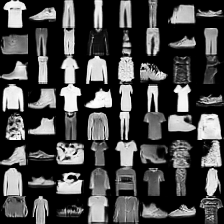

[DONE] Saved models and final EMA grid in: dcgan_select_runs/1762246906_finetune_v6_ttur_smooth_ema


In [ ]:
# === Finetune best model "v6_ttur_smooth" with EMA for 50 epochs ===

import os, time, json
from pathlib import Path
import numpy as np
import tensorflow as tf
from IPython.display import display

# ---------------------------
# 1) EMA Helper
# ---------------------------
class EMAHelper:
    def __init__(self, model, decay=0.999):
        self.decay = tf.constant(decay, dtype=tf.float32)
        # Store shadow weights as numpy arrays for robustness across graph/eager
        self.shadow = [w.numpy().copy() for w in model.weights]
        self._bak = None

    def update(self, model_weights):
        new_shadow = []
        for s, w in zip(self.shadow, model_weights):
            sw = tf.convert_to_tensor(s, dtype=w.dtype)
            updated = self.decay * sw + (1.0 - self.decay) * w
            new_shadow.append(updated.numpy())
        self.shadow = new_shadow

    def apply_to(self, model):
        self._bak = [w.numpy().copy() for w in model.weights]
        for w, s in zip(model.weights, self.shadow):
            w.assign(s)

    def restore(self, model):
        if self._bak is not None:
            for w, b in zip(model.weights, self._bak):
                w.assign(b)
            self._bak = None

# ---------------------------
# 2) Locate/load best run if models aren't already in memory
# ---------------------------
best_run_suffix = "v6_ttur_smooth"
runs_root = Path("dcgan_select_runs")

def _find_best_run_dir():
    if not runs_root.exists():
        return None
    candidates = sorted(
        [p for p in runs_root.iterdir() if p.is_dir() and p.name.endswith(best_run_suffix)],
        key=lambda p: p.stat().st_mtime
    )
    return candidates[-1] if candidates else None

try:
    generator
    discriminator
    _have_models = True
except NameError:
    _have_models = False

if not _have_models:
    best_dir = _find_best_run_dir()
    assert best_dir is not None, f"Could not find a run directory ending with _{best_run_suffix} in {runs_root}"
    print(f"[INFO] Loading models from: {best_dir}")
    generator = tf.keras.models.load_model(best_dir / "generator.keras", compile=False)
    discriminator = tf.keras.models.load_model(best_dir / "discriminator.keras", compile=False)

# ---------------------------
# 3) Dataset & optimizers
# ---------------------------

try:
    train_ds
except NameError as e:
    raise RuntimeError("A batched dataset `train_ds` (values in [-1, 1]) is required.") from e

try:
    g_optimizer
    d_optimizer
except NameError:
    g_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.999)
    d_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, beta_2=0.999)

bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
latent_dim = int(generator.inputs[0].shape[1])

# ---------------------------
# 4) Training step fallback 
# ---------------------------
@tf.function
def _fallback_train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    # --- D update ---
    z = tf.random.normal((batch_size, latent_dim))
    with tf.GradientTape() as d_tape:
        fake = generator(z, training=True)
        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(fake, training=True)
        d_loss_real = bce(tf.ones_like(real_logits), real_logits)
        d_loss_fake = bce(tf.zeros_like(fake_logits), fake_logits)
        d_loss = d_loss_real + d_loss_fake
    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # --- G update ---
    z = tf.random.normal((batch_size, latent_dim))
    with tf.GradientTape() as g_tape:
        fake = generator(z, training=True)
        fake_logits = discriminator(fake, training=True)
        g_loss = bce(tf.ones_like(fake_logits), fake_logits)
    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    return {"d_loss": d_loss, "g_loss": g_loss}

_use_user_step = False
try:
    train_step 
    _use_user_step = True
    print("[INFO] Using your existing `train_step`.")
except NameError:
    train_step = _fallback_train_step
    print("[WARN] `train_step` not found: using a minimal DCGAN fallback.")

# ---------------------------
# 5) EMA setup & utilities
# ---------------------------
ema_decay = 0.999  
emaG = EMAHelper(generator, decay=ema_decay)

def _make_grid(samples, rows=8, cols=8):
    
    x = (samples + 1.0) * 127.5
    x = tf.clip_by_value(x, 0, 255)
    x = tf.cast(x, tf.uint8)
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    grid = tf.reshape(x[:rows*cols], (rows, cols, h, w, c))
    grid = tf.transpose(grid, [0,2,1,3,4])
    grid = tf.reshape(grid, (rows*h, cols*w, c))
    return grid

timestamp_dir = runs_root / f"{int(time.time())}_finetune_{best_run_suffix}_ema"
timestamp_dir.mkdir(parents=True, exist_ok=True)

def _save_ema_grid(tag):
    emaG.apply_to(generator)
    z = tf.random.normal((64, latent_dim))
    imgs = generator(z, training=False)
    emaG.restore(generator)
    grid = _make_grid(imgs)
    out_path = timestamp_dir / f"grid_ema_{tag}.png"
    tf.keras.utils.save_img(str(out_path), grid)
    return out_path

# ---------------------------
# 6) Train 50 epochs (update EMA after each G update)
# ---------------------------
EPOCHS = 50
global_step = 0
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    d_vals, g_vals = [], []
    for real_batch in train_ds:
        out = train_step(real_batch)
        # Update EMA after the generator step
        emaG.update(generator.weights)
        global_step += 1
        # Log (only if using fallback)
        if isinstance(out, dict) and "d_loss" in out and "g_loss" in out:
            d_vals.append(float(out["d_loss"]))
            g_vals.append(float(out["g_loss"]))
    dt = time.time() - t0
    if d_vals and g_vals:
        print(f"[E{epoch:03d}] {dt:.1f}s  d_loss={np.mean(d_vals):.3f}  g_loss={np.mean(g_vals):.3f}")
    else:
        print(f"[E{epoch:03d}] {dt:.1f}s")

# ---------------------------
# 7) Save final models and show only the final EMA grid inline
# ---------------------------
# Save live generator
generator.save(timestamp_dir / "generator.keras")

# Save EMA-smoothed generator
emaG.apply_to(generator)
generator.save(timestamp_dir / "generator_ema.keras")

# Create & display final EMA grid
final_grid_path = _save_ema_grid("final")
display(tf.keras.utils.load_img(str(final_grid_path)))
print(f"[DONE] Saved models and final EMA grid in: {timestamp_dir}")

# Restore live weights after saving
emaG.restore(generator)


In the EMA grid, the shapes of the garments are noticeably more regular: items such as boots, skirts, and tops present smoother outlines and more anatomically plausible proportions. High-frequency noise inside each item is strongly reduced; instead of chaotic speckling, the interior texture looks uniform and fabric-like. The silhouettes also tend to fill the frame more confidently, with less wasted black background area per tile, suggesting better mode stability in terms of pose and positioning. Edges appear sharper at the native 28×28 scale, rather than blocky, and the transition between foreground (clothing) and background is cleaner. Visually, there are fewer “collapsed” or incoherent samples, and almost every tile is interpretable as a plausible article of clothing. This supports the intended effect of EMA: averaging generator weights over time suppresses transient, noisy updates and yields a generator that produces more consistent, higher-fidelity samples.

In [ ]:
# ==== CONFIGURE HERE ====
OWNER = "YOUR_KAGGLE_USERNAME"
DATASET_SLUG = "risultati-output-gan"  
DATASET_TITLE = "Results Output GAN"    
OUTPUT_DIR = "."                    
DATASET_DIR = "_kaggle_dataset_bundle"  
APPEND_TARGET = "results.csv"       
VERSION_MESSAGE = "Updating with new output folder"
# ========================

import os, json, shutil, sys, subprocess, zipfile
from pathlib import Path

def run(cmd):
    print(">", " ".join(cmd))
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.stdout: print(r.stdout)
    if r.returncode != 0:
        print(r.stderr, file=sys.stderr)
        raise RuntimeError(f"Command failed: {' '.join(cmd)}")
    return r.stdout

# 0) (OPTIONAL) Set credentials manually here
KAGGLE_USERNAME_MANUAL = ""  
KAGGLE_KEY_MANUAL = ""       

if KAGGLE_USERNAME_MANUAL and KAGGLE_KEY_MANUAL:
    os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME_MANUAL
    os.environ["KAGGLE_KEY"] = KAGGLE_KEY_MANUAL
    # also write to ~/.kaggle/kaggle.json
    kdir = (Path.home()/".kaggle"); kdir.mkdir(parents=True, exist_ok=True)
    with open(kdir/"kaggle.json", "w", encoding="utf-8") as f:
        json.dump({"username": KAGGLE_USERNAME_MANUAL, "key": KAGGLE_KEY_MANUAL}, f)
    os.chmod(kdir/"kaggle.json", 0o600)

# 1) Ensure kaggle CLI is installed
try:
    import kaggle 
except Exception:
    run([sys.executable, "-m", "pip", "install", "--quiet", "kaggle"])

# 2) Check credentials
home = Path.home()
kcfg = home/".kaggle"/"kaggle.json"
if not (os.getenv("KAGGLE_USERNAME") and os.getenv("KAGGLE_KEY")) and not kcfg.exists():
    raise RuntimeError(
        "Missing Kaggle credentials. Place kaggle.json in ~/.kaggle or export KAGGLE_USERNAME and KAGGLE_KEY."
    )

# 3) Prepare staging folder 
staging = Path(DATASET_DIR).resolve()
if staging.exists():
    shutil.rmtree(staging)
staging.mkdir(parents=True, exist_ok=True)

# 3b) Exclusion rules to avoid recursion and “junk” files
EXCLUDE_DIRS = {}
EXCLUDE_FILES = {}
EXCLUDE_GLOBS = {}

output_dir = Path(OUTPUT_DIR).resolve()
if not output_dir.exists():
    raise RuntimeError(f"OUTPUT_DIR does not exist: {output_dir}")

def should_skip(path: Path) -> bool:
    try:
        rp = path.resolve()
    except Exception:
        return True  
    
    if rp == staging or staging in rp.parents:
        return True
    
    if any(seg in EXCLUDE_DIRS for seg in rp.parts):
        return True
    
    if rp.name in EXCLUDE_FILES:
        return True
    
    for pat in EXCLUDE_GLOBS:
        if rp.match(pat):
            return True
        
    if rp.is_symlink():
        return True
    return False

# 4) Recursive copy preserving structure, with exclusions
base = output_dir
for src in base.rglob("*"):
    if src.is_file() and not should_skip(src):
        rel = src.relative_to(base)
        dst = staging / rel
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)

# 5) Optional CSV append handling
dataset_ref = f"{OWNER}/{DATASET_SLUG}"

def kaggle_dataset_exists(ref: str) -> bool:
    try:
        run(["kaggle", "datasets", "files", ref])
        return True
    except Exception:
        return False

def download_existing_csv_if_any(ref: str, filename: str, dest_folder: Path):
    try:
        tmpd = dest_folder / "__existing__"
        if tmpd.exists():
            shutil.rmtree(tmpd)
        tmpd.mkdir(parents=True)
        run(["kaggle", "datasets", "download", ref, "-p", str(tmpd), "-f", filename, "-q"])
        for z in tmpd.glob("*.zip"):
            with zipfile.ZipFile(z, 'r') as zf:
                zf.extractall(tmpd)
            z.unlink()
        matches = list(tmpd.glob(filename))
        return matches[0] if matches else None
    except Exception:
        return None

if APPEND_TARGET:
    if kaggle_dataset_exists(dataset_ref):
        existing_csv = download_existing_csv_if_any(dataset_ref, APPEND_TARGET, staging)
        new_csv_path = staging / APPEND_TARGET
        pieces = []
        if existing_csv and existing_csv.exists():
            pieces.append(existing_csv)
        if new_csv_path.exists():
            pieces.append(new_csv_path)
        if pieces:
            import pandas as pd
            dfs = []
            for p in pieces:
                try:
                    df = pd.read_csv(p)
                except Exception:
                    df = pd.read_csv(p, sep=";")
                dfs.append(df)
            base_cols = list(dfs[0].columns)
            merged = pd.concat(dfs, axis=0, ignore_index=True, sort=False)
            ordered_cols = base_cols + [c for c in merged.columns if c not in base_cols]
            merged = merged[ordered_cols]
            merged.to_csv(staging / APPEND_TARGET, index=False)
            print(f"[OK] Append completed for {APPEND_TARGET} ({len(merged)} total rows).")

# 6) Create metadata if necessary
metadata_path = staging / "dataset-metadata.json"
if not metadata_path.exists():
    meta = {
        "title": DATASET_TITLE,
        "id": f"{OWNER}/{DATASET_SLUG}",
        "licenses": [{"name": "CC0-1.0"}],
        "description": "Dataset automatically generated/updated from notebook (uploading the entire folder).",
    }
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

# 7) Create or version the dataset
if kaggle_dataset_exists(dataset_ref):
    print(f"Existing dataset: {dataset_ref} → creating a new version…")
    run([
        "kaggle", "datasets", "version",
        "-p", str(staging),
        "-m", VERSION_MESSAGE,
        "--dir-mode", "zip"
    ])
else:
    print(f"Dataset not found: {dataset_ref} → creating it…")
    run([
        "kaggle", "datasets", "create",
        "-p", str(staging),
        "-r", "zip"
    ])
    print("Created. Now immediately creating the first version for consistency…")
    run([
        "kaggle", "datasets", "version",
        "-p", str(staging),
        "-m", VERSION_MESSAGE,
        "--dir-mode", "zip"
    ])

print("\n Operation completed.")
print(f"Dataset: https://www.kaggle.com/datasets/{OWNER}/{DATASET_SLUG}")
